## Simple Linear Regression 
#### Dataset : California Housing dataset


### Import Libraries

In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as w
import math
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
w.filterwarnings("ignore")

### Load Dataset

In [98]:
df = pd.read_csv("/kaggle/input/california-housing-with-name-of-counties/California_Housing_CitiesAdded.csv")
df.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco,ocean_proximity,City
0,500001.0,1.2434,52,249,78,396,85,37.80,-122.27,2524.614616,552234.0515,731023.5749,61415.35211,14466.70538,NEAR BAY,Alameda
1,500001.0,1.1696,52,609,236,1349,250,37.87,-122.25,7897.024567,556856.9280,735788.3723,67242.51828,19172.81885,NEAR BAY,Alameda
2,500001.0,7.8521,52,1668,225,517,214,37.86,-122.24,9154.528309,555442.5086,734372.6023,65849.13943,19335.74118,NEAR BAY,Alameda
3,500001.0,9.3959,52,3726,474,1366,496,37.85,-122.24,8259.085109,554610.7171,733525.6829,64867.28983,18811.48745,NEAR BAY,Alameda
4,500001.0,7.8772,52,2990,379,947,361,37.83,-122.23,7284.913015,552365.4712,731263.5682,62493.11252,18750.94628,NEAR BAY,Alameda


### Data Spread Check 

In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df.shape

(20640, 16)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Median_House_Value        20640 non-null  float64
 1   Median_Income             20640 non-null  float64
 2   Median_Age                20640 non-null  int64  
 3   Tot_Rooms                 20640 non-null  int64  
 4   Tot_Bedrooms              20640 non-null  int64  
 5   Population                20640 non-null  int64  
 6   Households                20640 non-null  int64  
 7   Latitude                  20640 non-null  float64
 8   Longitude                 20640 non-null  float64
 9   Distance_to_coast         20640 non-null  float64
 10  Distance_to_LA            20640 non-null  float64
 11  Distance_to_SanDiego      20640 non-null  float64
 12  Distance_to_SanJose       20640 non-null  float64
 13  Distance_to_SanFrancisco  20640 non-null  float64
 14  ocean_

In [102]:
df.describe()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,2.064000e+04,2.064000e+04,20640.000000,20640.000000
mean,206855.816909,3.870671,28.639486,2635.763081,537.898014,1425.476744,499.539680,35.631861,-119.569704,40509.264883,2.694220e+05,3.981649e+05,349187.551219,386688.422291
std,115395.615874,1.899822,12.585558,2181.615252,421.247906,1132.462122,382.329753,2.135952,2.003532,49140.039160,2.477324e+05,2.894006e+05,217149.875026,250122.192316
min,14999.000000,0.499900,1.000000,2.000000,1.000000,3.000000,1.000000,32.540000,-124.350000,120.676447,4.205891e+02,4.849180e+02,569.448118,456.141313
25%,119600.000000,2.563400,18.000000,1447.750000,295.000000,787.000000,280.000000,33.930000,-121.800000,9079.756762,3.211125e+04,1.594264e+05,113119.928650,117395.477500
50%,179700.000000,3.534800,29.000000,2127.000000,435.000000,1166.000000,409.000000,34.260000,-118.490000,20522.019100,1.736675e+05,2.147398e+05,459758.877000,526546.661700
75%,264725.000000,4.743250,37.000000,3148.000000,647.000000,1725.000000,605.000000,37.710000,-118.010000,49830.414478,5.271562e+05,7.057954e+05,516946.491000,584552.007950
max,500001.000000,15.000100,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,41.950000,-114.310000,333804.686400,1.018260e+06,1.196919e+06,836762.678200,903627.663300


In [103]:
df.isnull().sum()

Median_House_Value          0
Median_Income               0
Median_Age                  0
Tot_Rooms                   0
Tot_Bedrooms                0
Population                  0
Households                  0
Latitude                    0
Longitude                   0
Distance_to_coast           0
Distance_to_LA              0
Distance_to_SanDiego        0
Distance_to_SanJose         0
Distance_to_SanFrancisco    0
ocean_proximity             0
City                        0
dtype: int64

In [104]:
df.columns

Index(['Median_House_Value', 'Median_Income', 'Median_Age', 'Tot_Rooms',
       'Tot_Bedrooms', 'Population', 'Households', 'Latitude', 'Longitude',
       'Distance_to_coast', 'Distance_to_LA', 'Distance_to_SanDiego',
       'Distance_to_SanJose', 'Distance_to_SanFrancisco', 'ocean_proximity',
       'City'],
      dtype='object')

In [105]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns
print(numerical_cols)
print(categorical_cols)

Index(['Median_House_Value', 'Median_Income', 'Median_Age', 'Tot_Rooms',
       'Tot_Bedrooms', 'Population', 'Households', 'Latitude', 'Longitude',
       'Distance_to_coast', 'Distance_to_LA', 'Distance_to_SanDiego',
       'Distance_to_SanJose', 'Distance_to_SanFrancisco'],
      dtype='object')
Index(['ocean_proximity', 'City'], dtype='object')


## EDA

### Univariate analysis

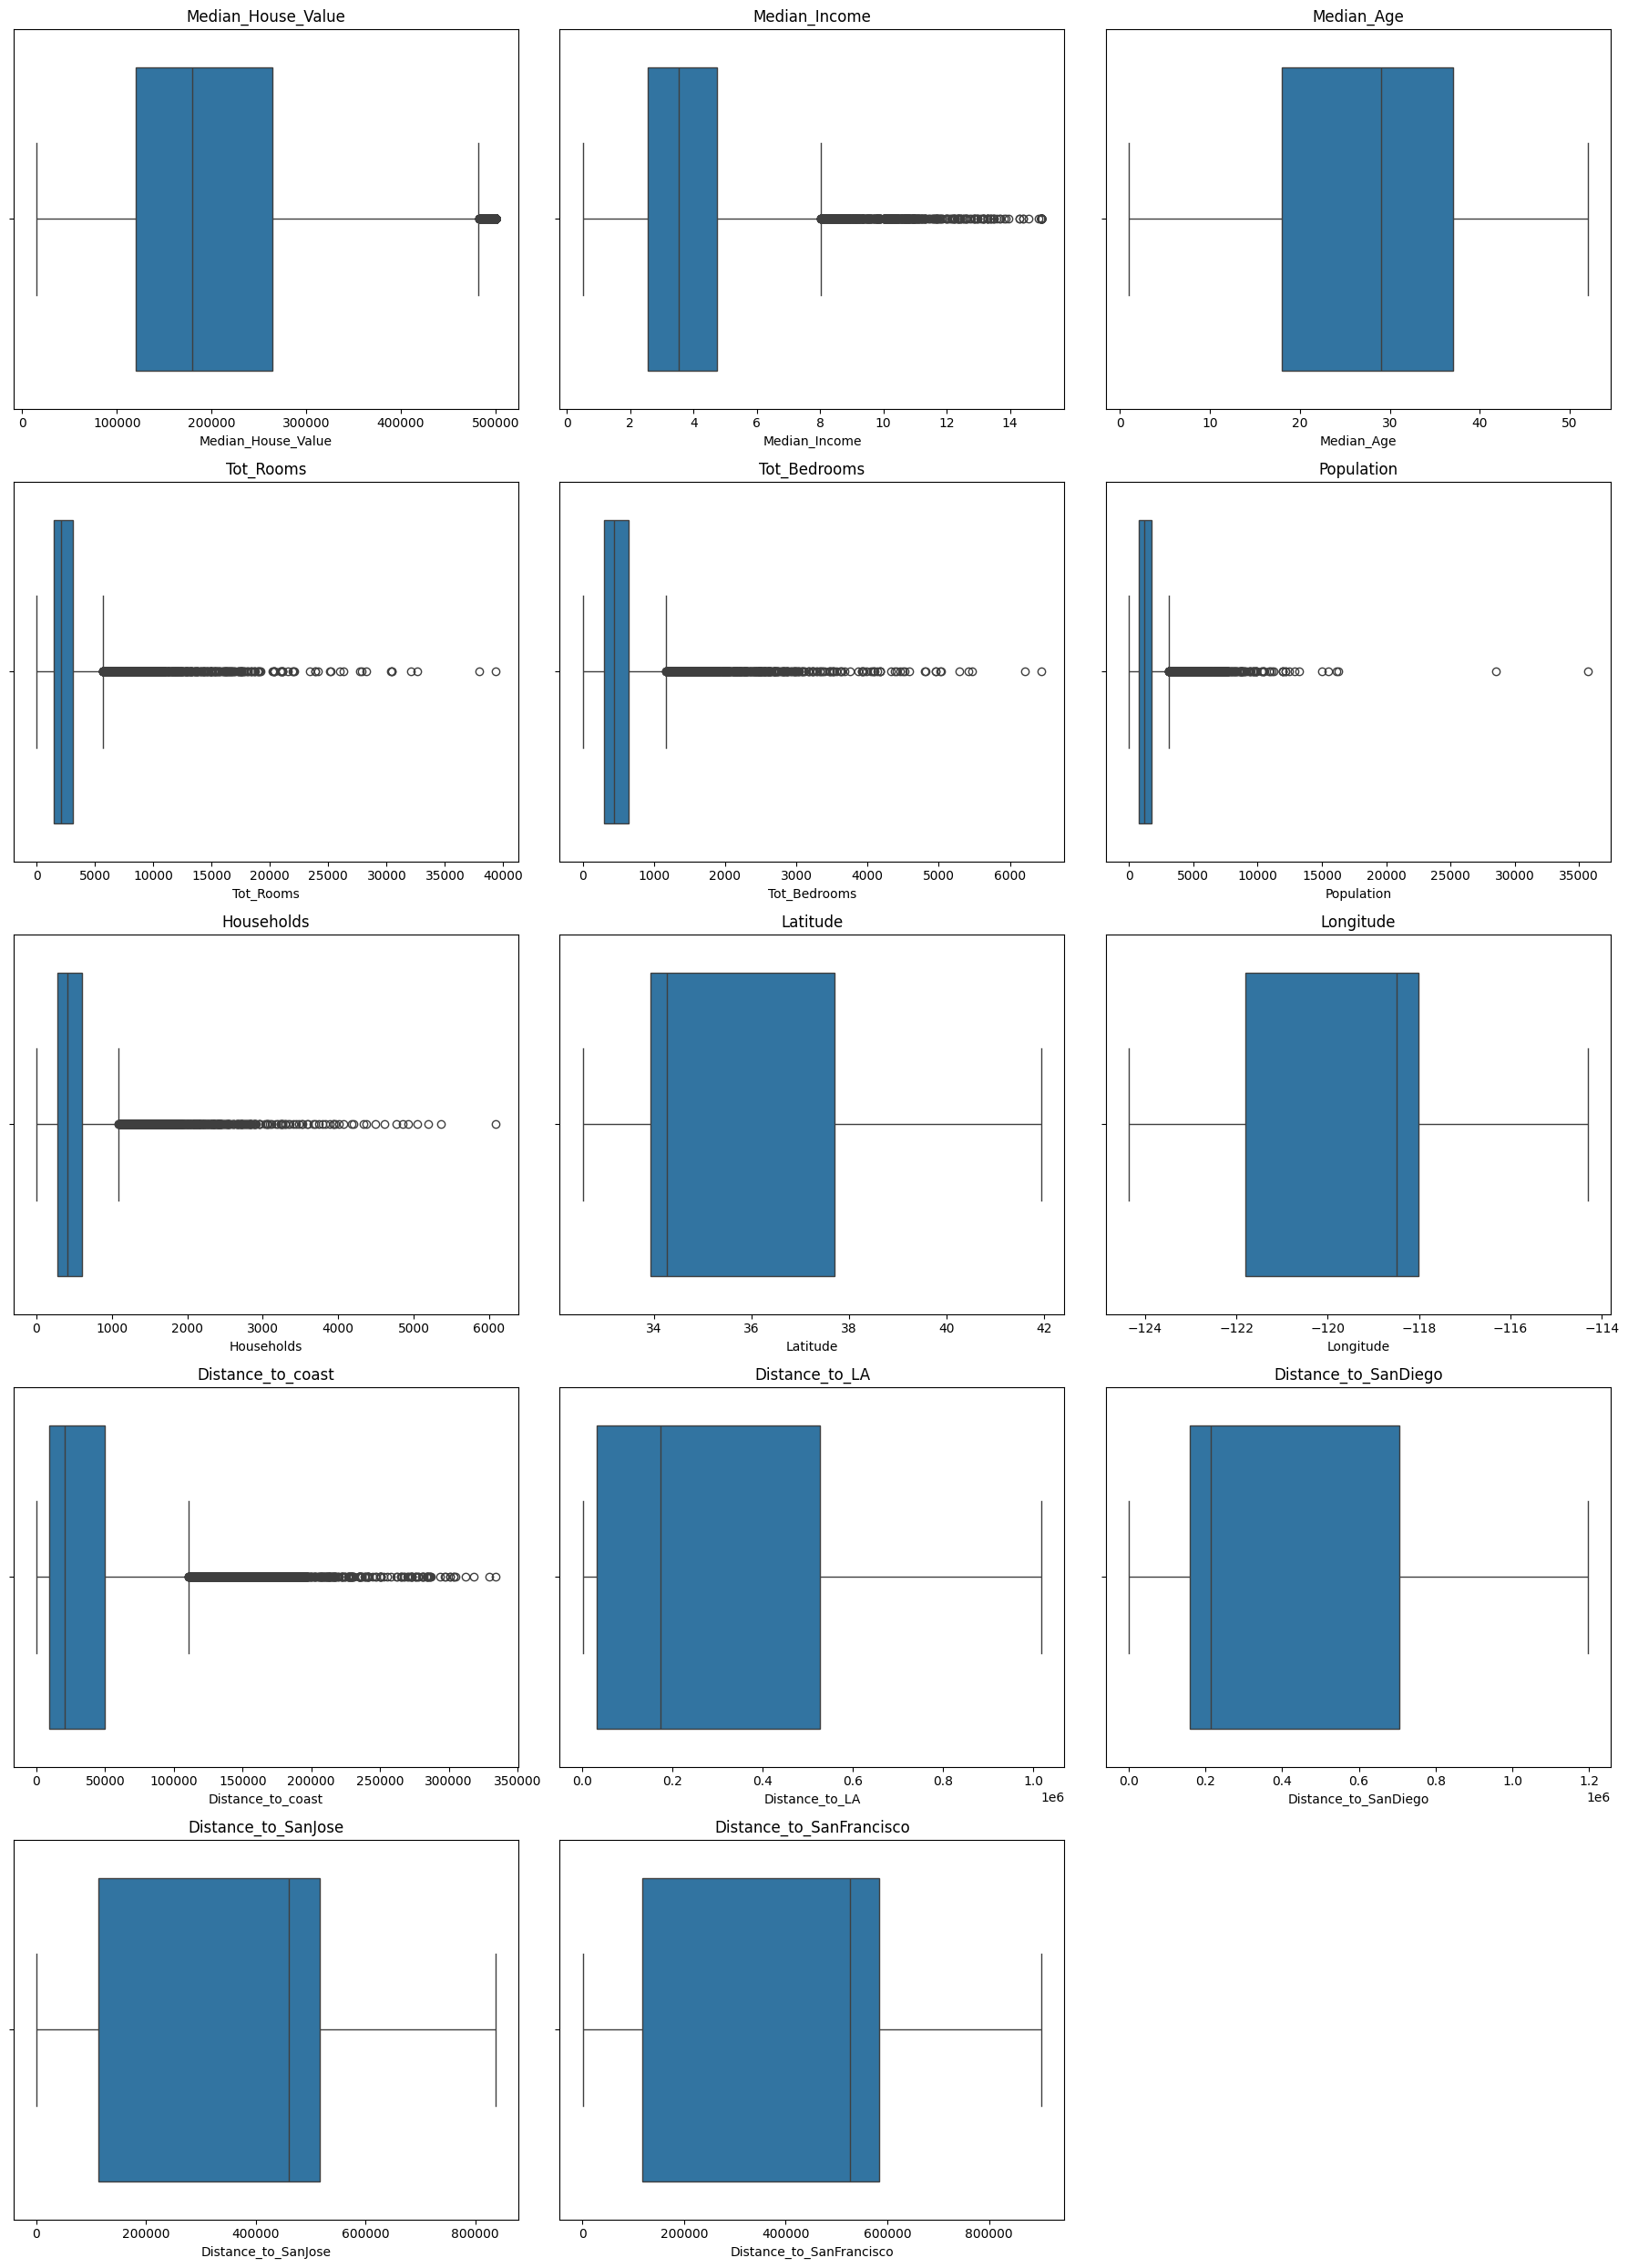

In [106]:
num_cols = numerical_cols
n_cols = 3                      # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


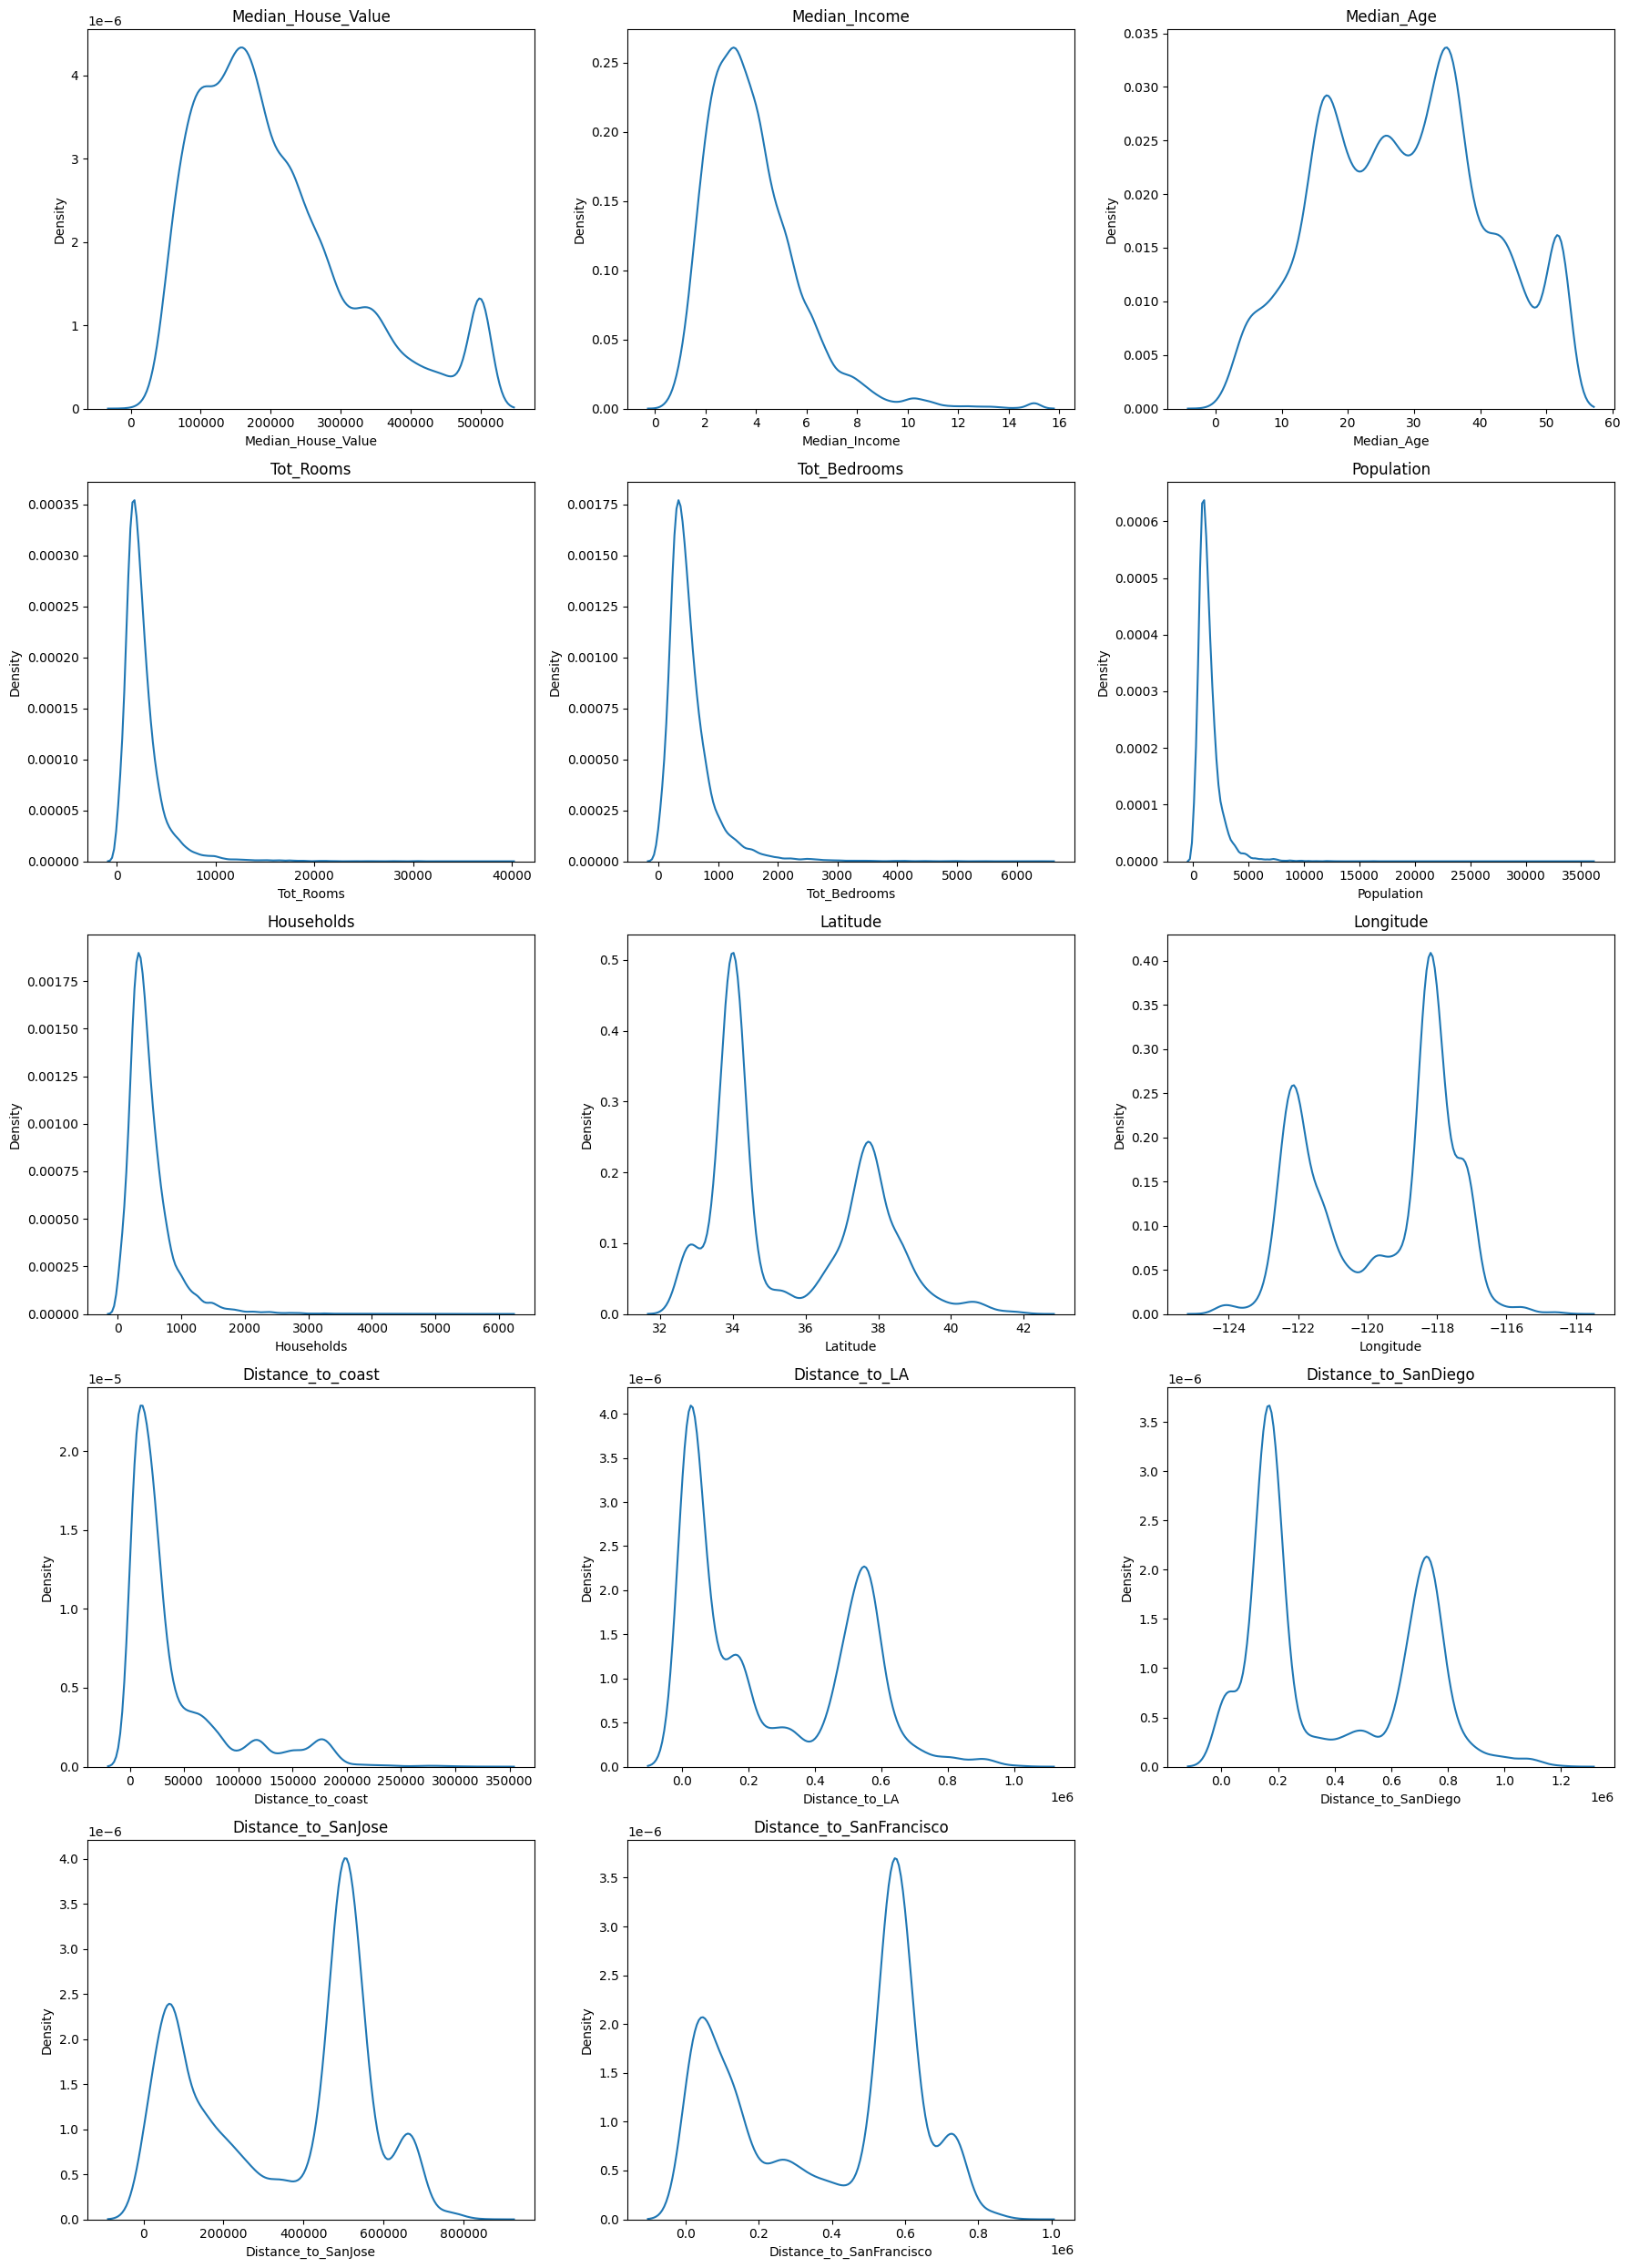

In [107]:
num_cols = numerical_cols
n_cols = 3                      # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [108]:
# def remove_outliers(df):
#     df_clean = df.copy()
    
#     numerical_cols = df_clean.select_dtypes(include=np.number).columns
    
#     for col in numerical_cols:
#         Q1 = df_clean[col].quantile(0.25)
#         Q3 = df_clean[col].quantile(0.75)
#         IQR = Q3 - Q1
        
#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR
        
#         df_clean = df_clean[
#             (df_clean[col] >= lower_bound) & 
#             (df_clean[col] <= upper_bound)
#         ]
        
#     return df_clean


In [109]:
# df_clean = remove_outliers(df)
df_clean=df.copy()

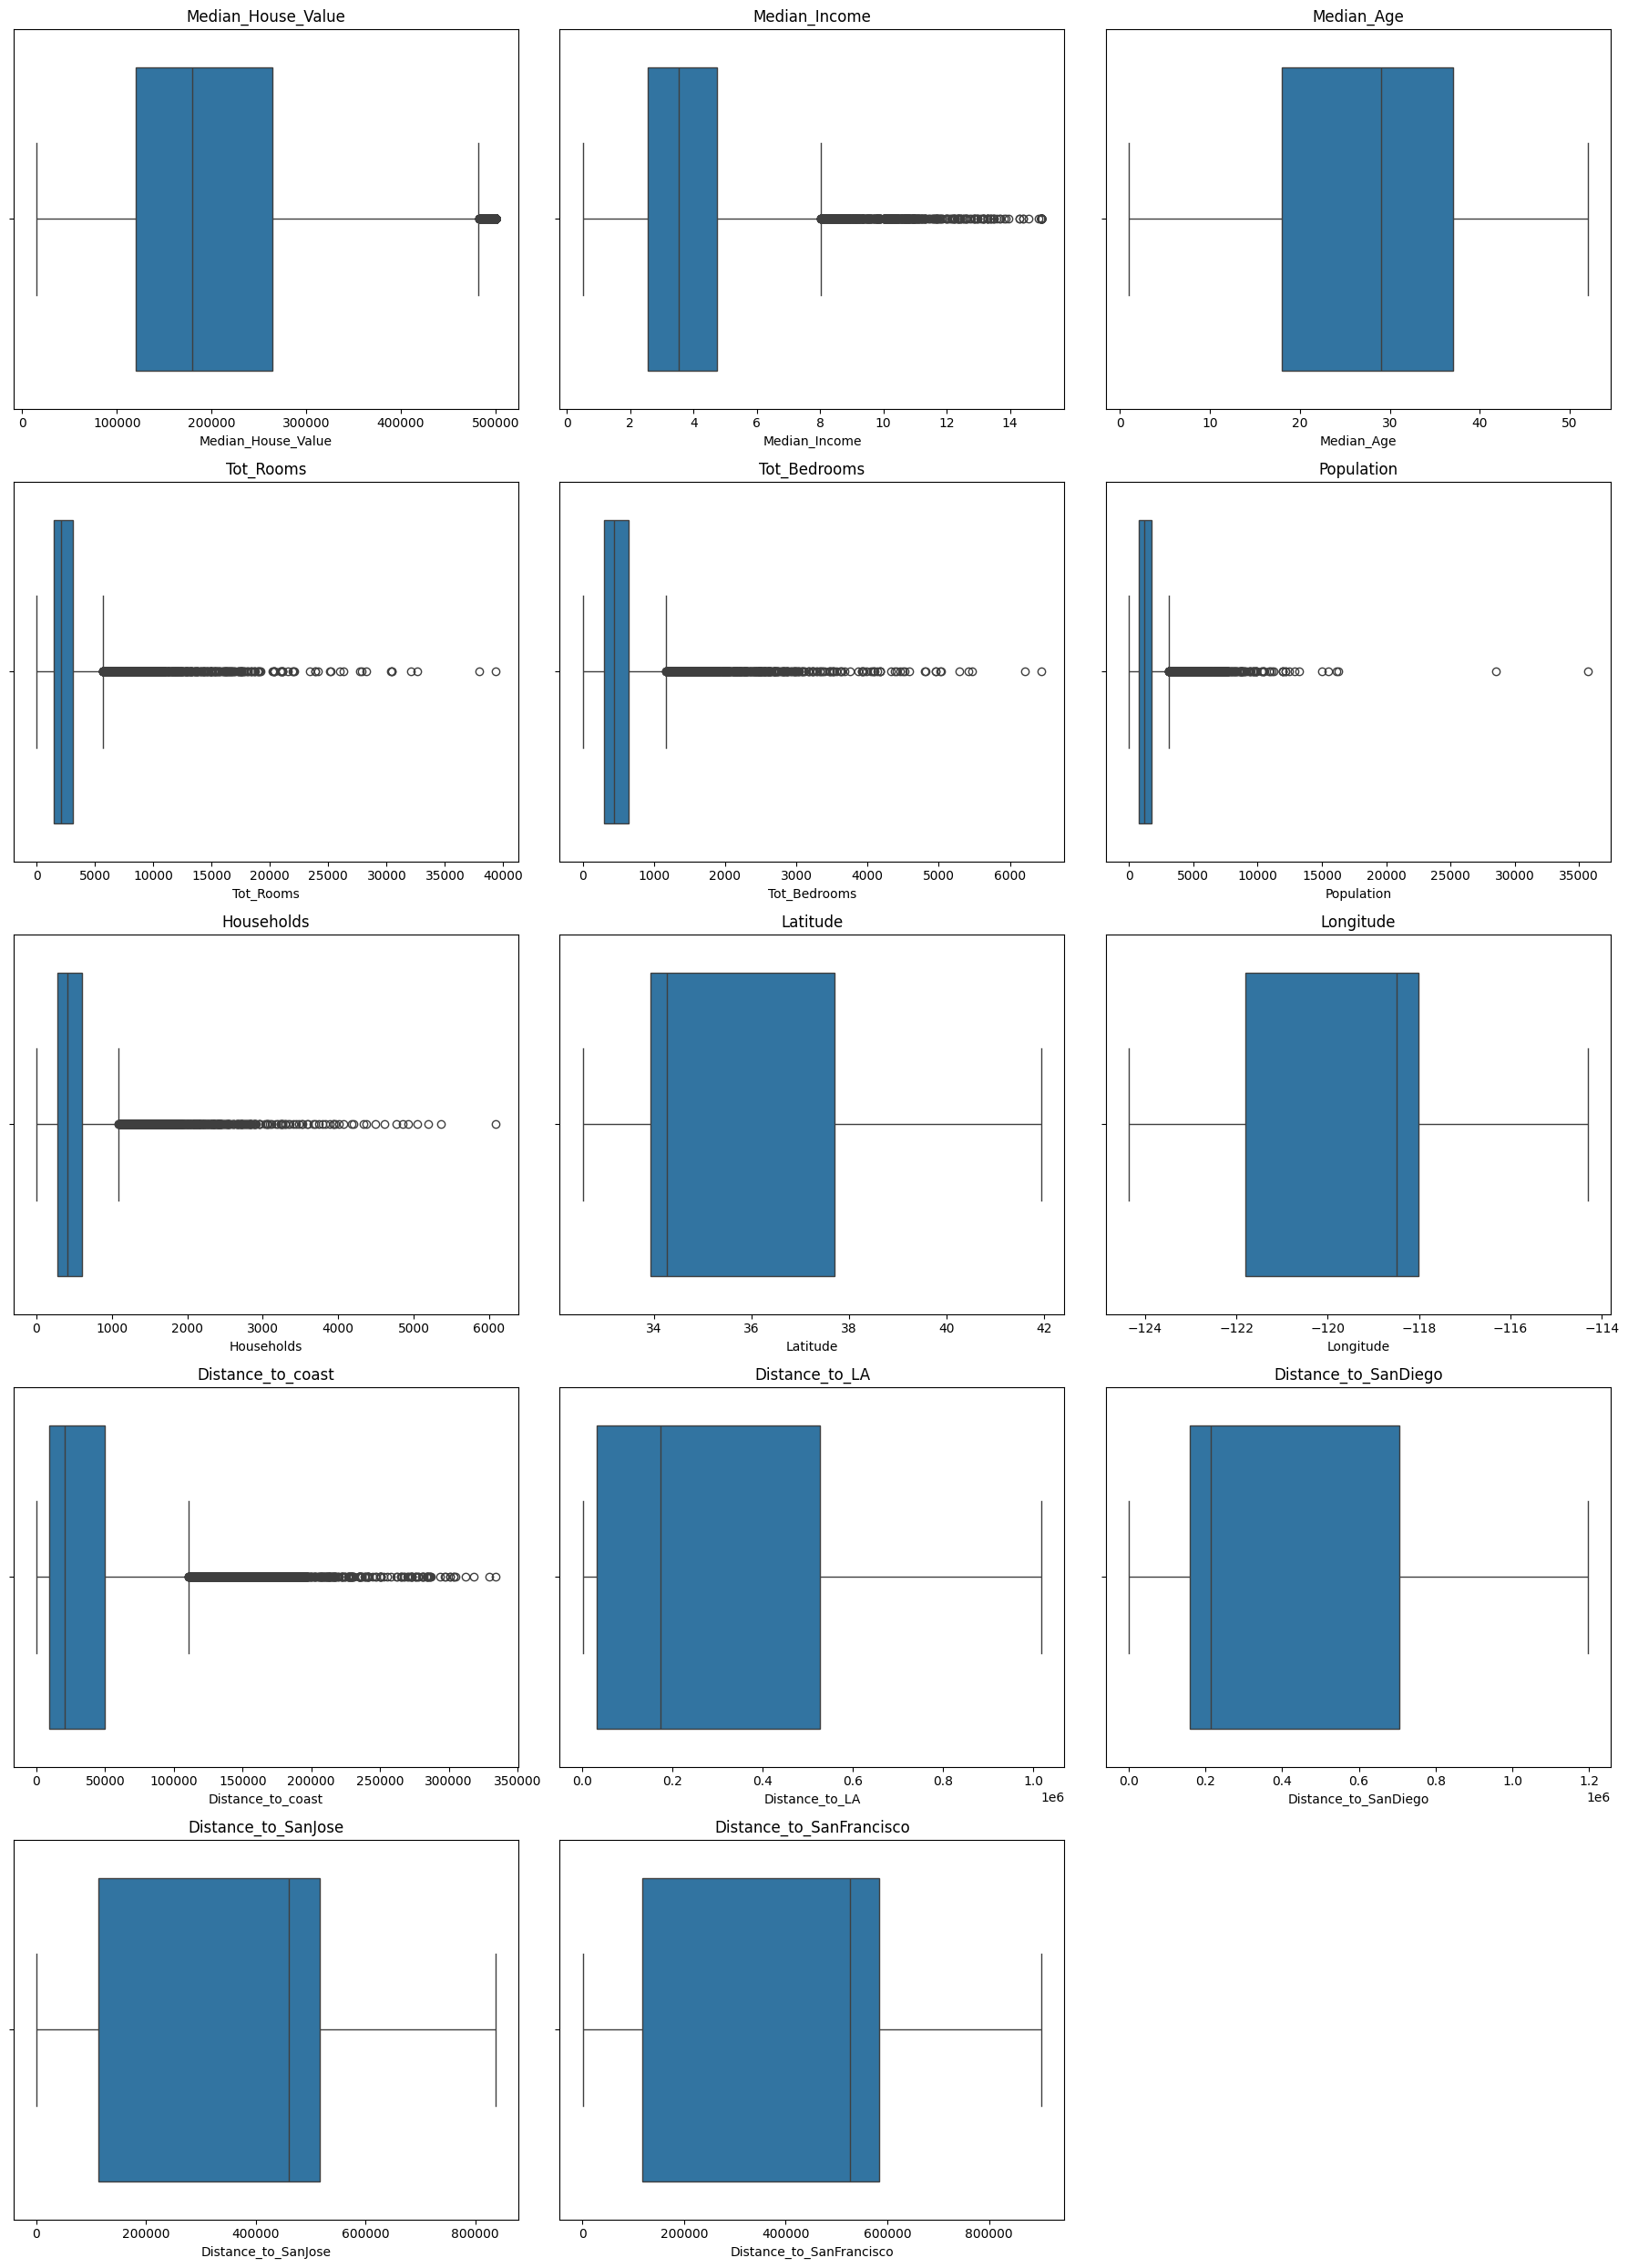

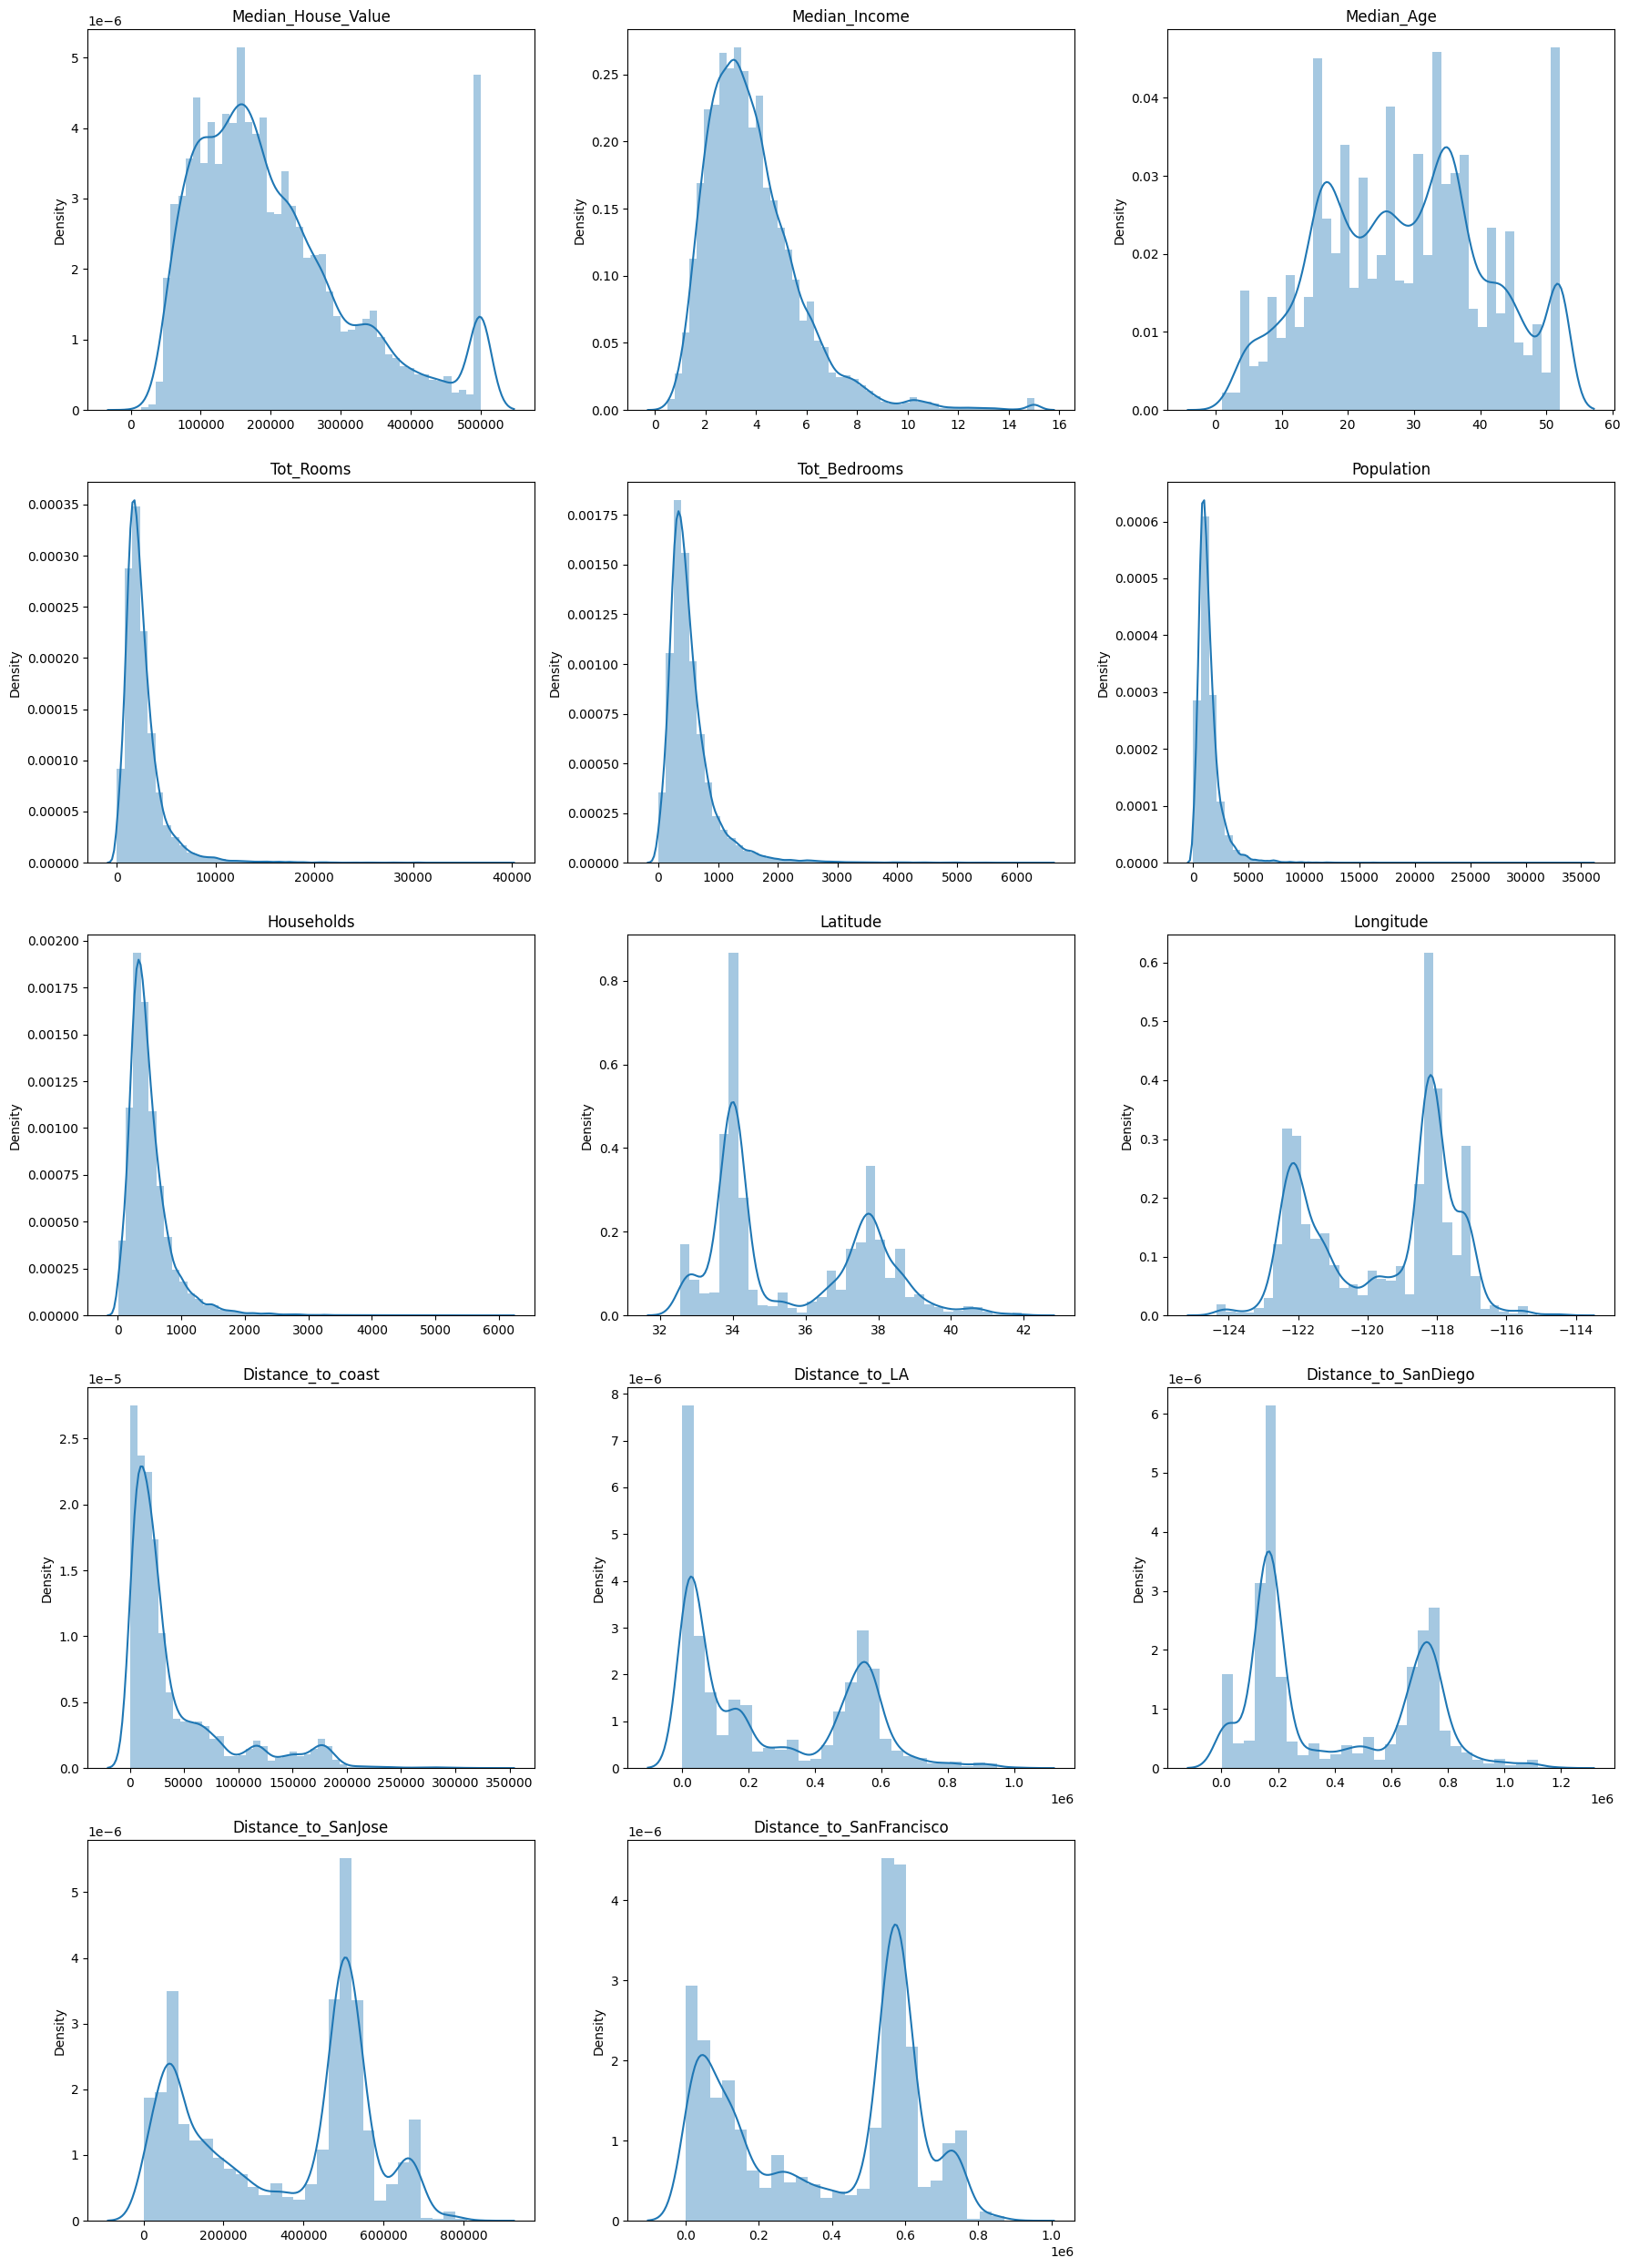

In [110]:
num_cols = numerical_cols
n_cols = 3                      # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df_clean[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


num_cols = numerical_cols
n_cols = 3                      # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.distplot(x=df_clean[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


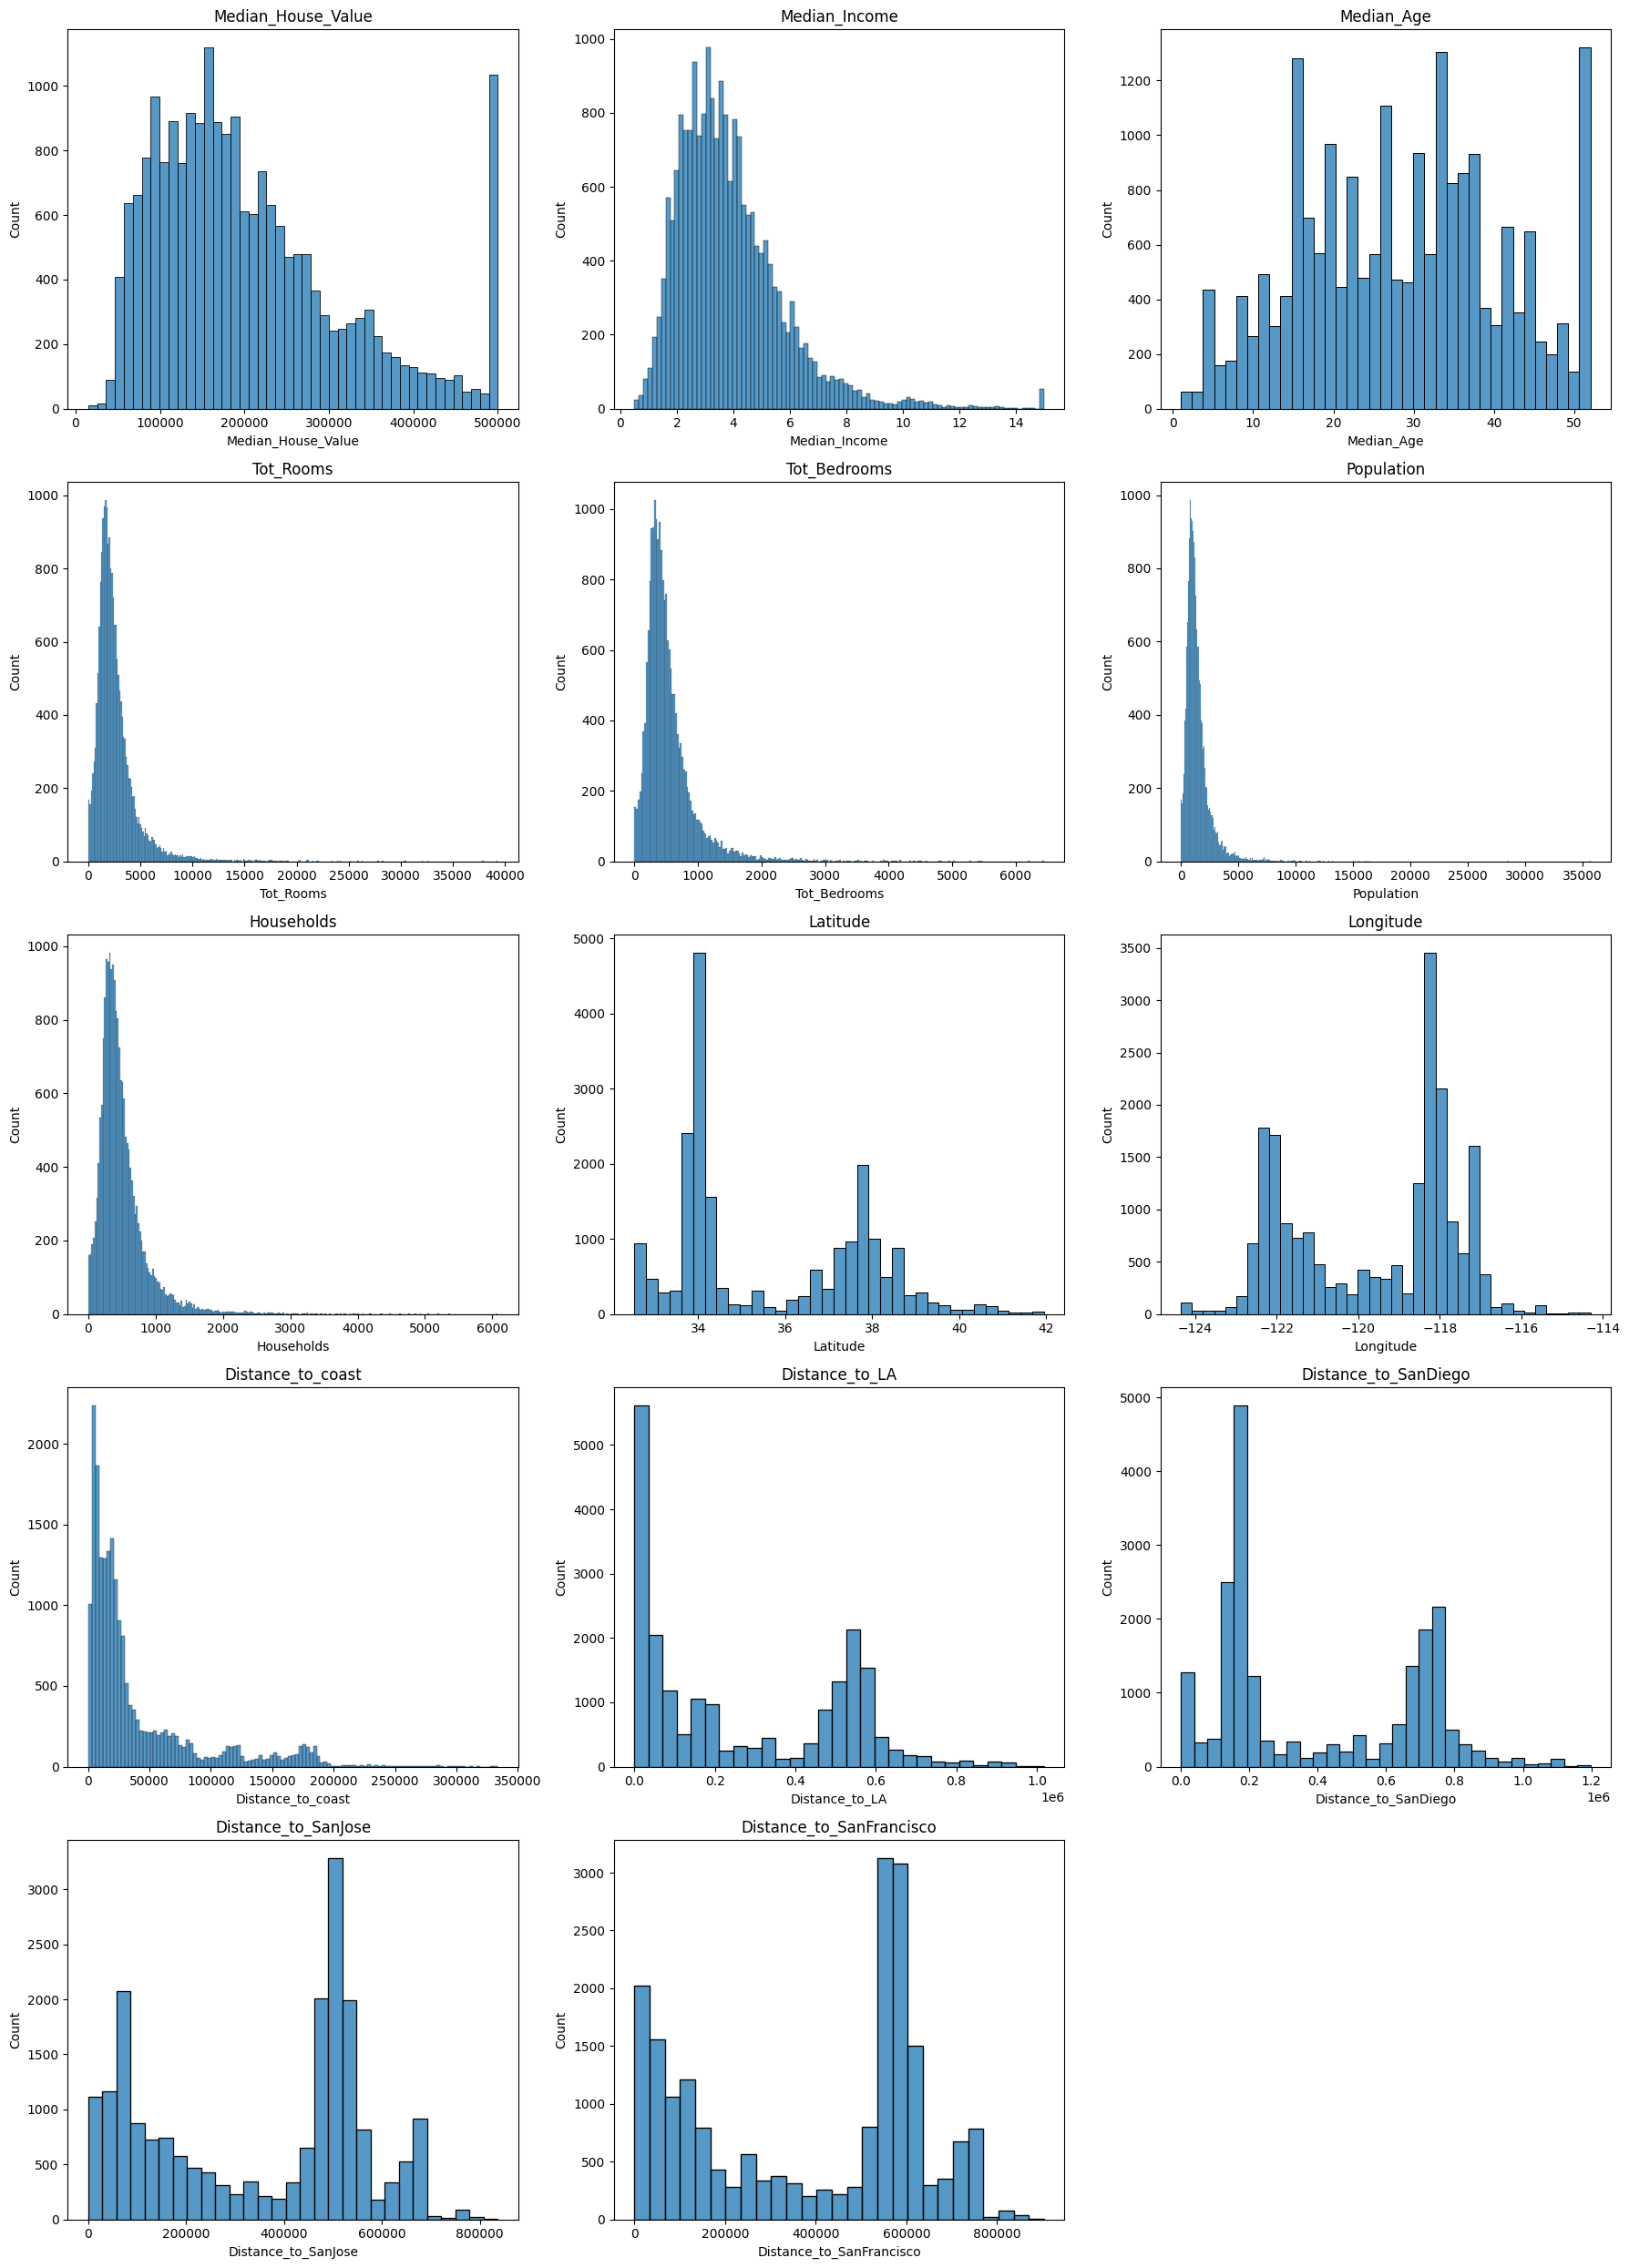

In [111]:
num_cols = numerical_cols
n_cols = 3                      # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(x=df_clean[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [112]:
df_clean['City'].value_counts()

City
Los Angeles        5836
Orange             1620
San Diego          1590
Alameda            1018
Santa Clara        1011
San Bernardino      827
Sacramento          702
Riverside           620
Contra Costa        593
San Francisco       574
Fresno              548
San Mateo           448
San Joaquin         418
Ventura             378
Kern                375
Santa Barbara       315
Sonoma              313
Stanislaus          306
Tulare              241
Solano              203
Santa Cruz          194
Monterey            188
Butte               163
Marin               162
Humboldt            135
San Luis Obispo     131
Shasta              129
Placer              126
Merced              126
Nevada              116
Napa                109
Imperial            109
El Dorado           106
Kings                96
Lake                 83
Mendocino            82
Yolo                 78
Tuolumne             66
Sutter               62
Madera               62
Siskiyou             48
Tehama     

In [113]:
df_clean['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

<Axes: xlabel='ocean_proximity', ylabel='Count'>

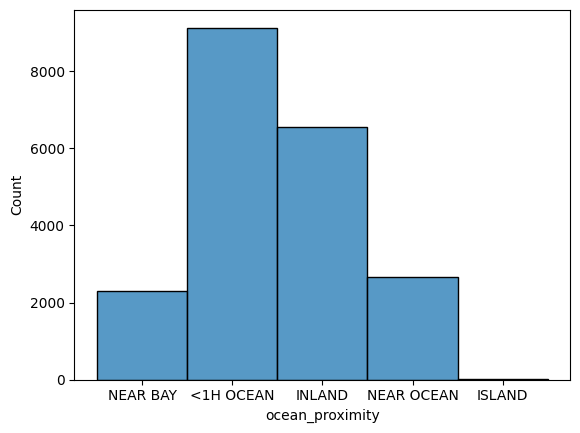

In [114]:
sns.histplot(df_clean['ocean_proximity'])

In [115]:
print("Skewness:")
print(df_clean[numerical_cols].skew())
print("\nKurtosis:")
print(df_clean[numerical_cols].kurtosis())


Skewness:
Median_House_Value          0.977763
Median_Income               1.646657
Median_Age                  0.060331
Tot_Rooms                   4.147343
Tot_Bedrooms                3.453073
Population                  4.935858
Households                  3.410438
Latitude                    0.465953
Longitude                  -0.297801
Distance_to_coast           1.938709
Distance_to_LA              0.466536
Distance_to_SanDiego        0.384936
Distance_to_SanJose        -0.223069
Distance_to_SanFrancisco   -0.263499
dtype: float64

Kurtosis:
Median_House_Value           0.327870
Median_Income                4.952524
Median_Age                  -0.800629
Tot_Rooms                   32.630927
Tot_Bedrooms                21.923495
Population                  73.553116
Households                  22.057988
Latitude                    -1.117760
Longitude                   -1.330152
Distance_to_coast            3.339845
Distance_to_LA              -1.220409
Distance_to_SanDiego        

In [116]:
# threshold for skewness
SKEW_THRESHOLD = 1.0

# numerical columns
numerical_cols = df_clean.select_dtypes(include=np.number).columns

# apply log1p only to highly skewed features
for col in numerical_cols:
    skewness = df_clean[col].skew()
    
    if abs(skewness) > SKEW_THRESHOLD:
        df_clean[col] = np.log1p(df_clean[col])

# check skewness after transformation
df_clean[numerical_cols].skew()


Median_House_Value          0.977763
Median_Income               0.226083
Median_Age                  0.060331
Tot_Rooms                  -1.075533
Tot_Bedrooms               -0.986761
Population                 -1.044087
Households                 -1.051607
Latitude                    0.465953
Longitude                  -0.297801
Distance_to_coast          -0.051065
Distance_to_LA              0.466536
Distance_to_SanDiego        0.384936
Distance_to_SanJose        -0.223069
Distance_to_SanFrancisco   -0.263499
dtype: float64

Housing prices show strong spatial dependence, with significantly higher values concentrated near the California coast and major metropolitan areas such as the Bay Area and Los Angeles.

A clear inland price decline is observed, indicating that distance from the coast and urban centers plays a major role in determining house values.

Geographical features (latitude, longitude, and distance-based variables) are strong predictors, justifying their inclusion in the regression model.

In [117]:
df_clean['rooms_per_household'] = df_clean['Tot_Rooms'] / df_clean['Households']
df_clean['bedrooms_per_room'] = df_clean['Tot_Bedrooms'] / df_clean['Tot_Rooms']
df_clean['population_per_household'] = df_clean['Population'] / df_clean['Households']
df_clean.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco,ocean_proximity,City,rooms_per_household,bedrooms_per_room,population_per_household
0,500001.0,0.807993,52,5.521461,4.369448,5.983936,4.454347,37.80,-122.27,7.834240,552234.0515,731023.5749,61415.35211,14466.70538,NEAR BAY,Alameda,1.239567,0.791357,1.343392
1,500001.0,0.774543,52,6.413459,5.468060,7.207860,5.525453,37.87,-122.25,8.974368,556856.9280,735788.3723,67242.51828,19172.81885,NEAR BAY,Alameda,1.160712,0.852591,1.304483
2,500001.0,2.180655,52,7.419980,5.420535,6.249975,5.370638,37.86,-122.24,9.122113,555442.5086,734372.6023,65849.13943,19335.74118,NEAR BAY,Alameda,1.381583,0.730532,1.163730
3,500001.0,2.341411,52,8.223359,6.163315,7.220374,6.208590,37.85,-122.24,9.019190,554610.7171,733525.6829,64867.28983,18811.48745,NEAR BAY,Alameda,1.324513,0.749489,1.162965
4,500001.0,2.183486,52,8.003363,5.940171,6.854355,5.891644,37.83,-122.23,8.893698,552365.4712,731263.5682,62493.11252,18750.94628,NEAR BAY,Alameda,1.358426,0.742209,1.163403


### Bivariate Analysis

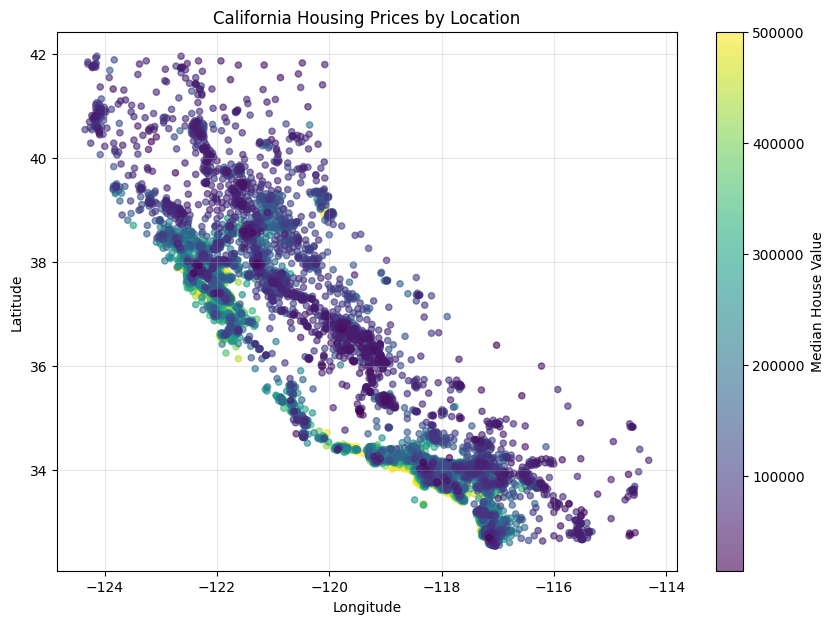

In [118]:
plt.figure(figsize=(10, 7))

sc = plt.scatter(
    df_clean['Longitude'],
    df_clean['Latitude'],
    c=df_clean['Median_House_Value'],
    cmap='viridis',          # better perceptual colormap than jet
    alpha=0.6,
    s=20                     # point size
)

plt.colorbar(sc, label='Median House Value')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by Location')

plt.grid(alpha=0.3)
plt.show()


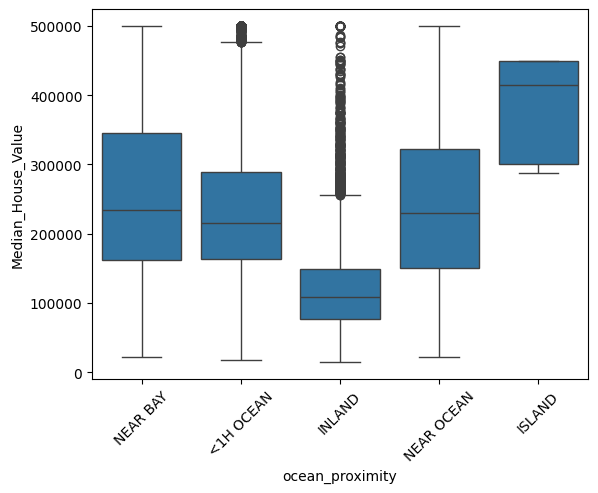

In [119]:
sns.boxplot(
    x=df_clean['ocean_proximity'],
    y=df_clean['Median_House_Value']
)
plt.xticks(rotation=45)
plt.show()


In [120]:
df_clean = pd.get_dummies(
    df_clean,
    columns=['ocean_proximity'],
    drop_first=True
)



In [121]:
# Convert all boolean columns to 0/1
df_clean = df_clean.astype({ 
    'ocean_proximity_INLAND': 'int',
    'ocean_proximity_ISLAND': 'int',
    'ocean_proximity_NEAR BAY': 'int',
    'ocean_proximity_NEAR OCEAN': 'int'
})

In [122]:
df_clean.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,...,Distance_to_SanJose,Distance_to_SanFrancisco,City,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,500001.0,0.807993,52,5.521461,4.369448,5.983936,4.454347,37.80,-122.27,7.834240,...,61415.35211,14466.70538,Alameda,1.239567,0.791357,1.343392,0,0,1,0
1,500001.0,0.774543,52,6.413459,5.468060,7.207860,5.525453,37.87,-122.25,8.974368,...,67242.51828,19172.81885,Alameda,1.160712,0.852591,1.304483,0,0,1,0
2,500001.0,2.180655,52,7.419980,5.420535,6.249975,5.370638,37.86,-122.24,9.122113,...,65849.13943,19335.74118,Alameda,1.381583,0.730532,1.163730,0,0,1,0
3,500001.0,2.341411,52,8.223359,6.163315,7.220374,6.208590,37.85,-122.24,9.019190,...,64867.28983,18811.48745,Alameda,1.324513,0.749489,1.162965,0,0,1,0
4,500001.0,2.183486,52,8.003363,5.940171,6.854355,5.891644,37.83,-122.23,8.893698,...,62493.11252,18750.94628,Alameda,1.358426,0.742209,1.163403,0,0,1,0


In [123]:
df_clean.drop(columns=["City"], inplace=True)

### Multivariate Anlaysis

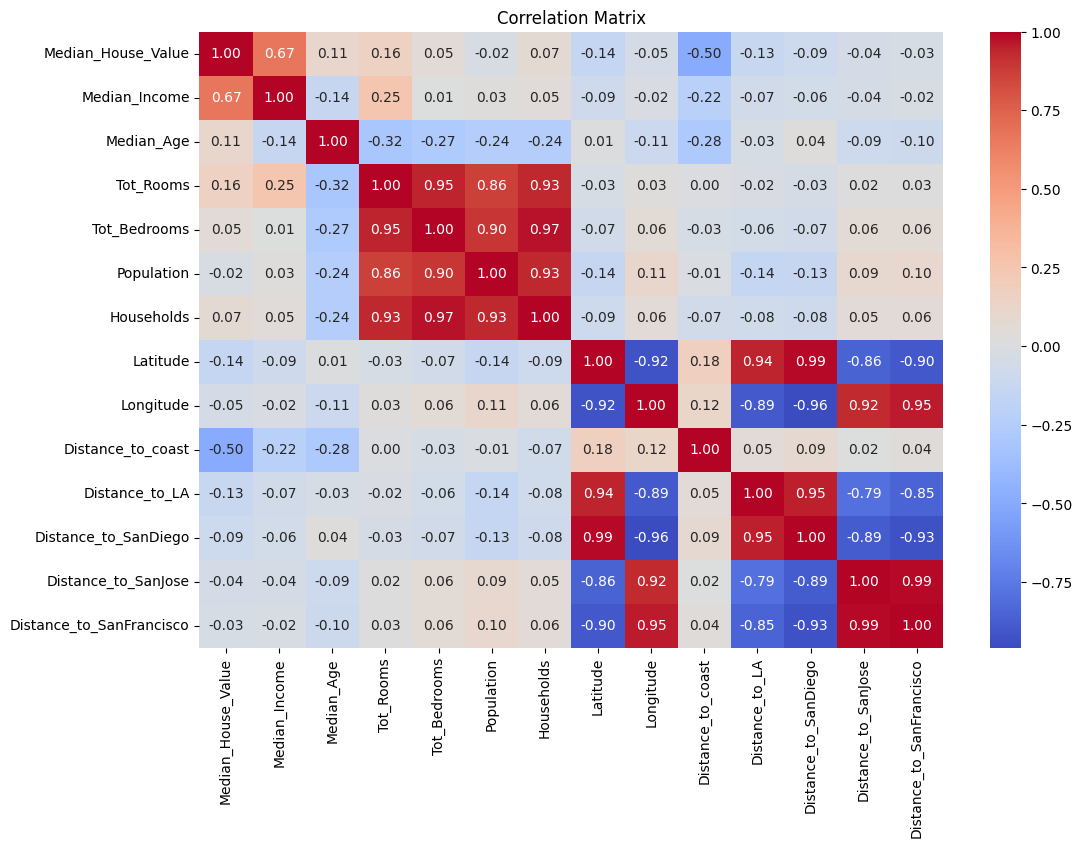

In [124]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df_clean[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()


In [125]:
corr_matrix = df_clean.corr()

In [126]:
corr_target = corr_matrix['Median_House_Value'].sort_values(ascending=False)
corr_target

Median_House_Value            1.000000
Median_Income                 0.669914
ocean_proximity_NEAR BAY      0.160284
Tot_Rooms                     0.159422
ocean_proximity_NEAR OCEAN    0.141862
rooms_per_household           0.113995
Median_Age                    0.105623
Households                    0.073612
Tot_Bedrooms                  0.054247
ocean_proximity_ISLAND        0.023416
Population                   -0.021205
Distance_to_SanFrancisco     -0.030559
Distance_to_SanJose          -0.041590
Longitude                    -0.045967
Distance_to_SanDiego         -0.092510
Distance_to_LA               -0.130678
Latitude                     -0.144160
population_per_household     -0.179463
bedrooms_per_room            -0.198053
ocean_proximity_INLAND       -0.484859
Distance_to_coast            -0.497700
Name: Median_House_Value, dtype: float64

In [127]:
LOW_CORR_THRESHOLD = 0.05

low_corr_features = corr_target[
    abs(corr_target) < LOW_CORR_THRESHOLD
].index.tolist()

low_corr_features


['ocean_proximity_ISLAND',
 'Population',
 'Distance_to_SanFrancisco',
 'Distance_to_SanJose',
 'Longitude']

In [128]:
df_model  =  df_clean.copy()
df_model.shape

(20640, 21)

In [129]:
# if 'Median_House_Value' in low_corr_features:
#     low_corr_features.remove('Median_House_Value')
    
# df_model.drop(columns=low_corr_features, inplace=True)


In [130]:
df_model.shape

(20640, 21)

In [131]:
df_model['income_rooms_interaction'] = (
    df_model['Median_Income'] * df_model['rooms_per_household']
)
df_model.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,...,Distance_to_SanJose,Distance_to_SanFrancisco,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,income_rooms_interaction
0,500001.0,0.807993,52,5.521461,4.369448,5.983936,4.454347,37.80,-122.27,7.834240,...,61415.35211,14466.70538,1.239567,0.791357,1.343392,0,0,1,0,1.001561
1,500001.0,0.774543,52,6.413459,5.468060,7.207860,5.525453,37.87,-122.25,8.974368,...,67242.51828,19172.81885,1.160712,0.852591,1.304483,0,0,1,0,0.899021
2,500001.0,2.180655,52,7.419980,5.420535,6.249975,5.370638,37.86,-122.24,9.122113,...,65849.13943,19335.74118,1.381583,0.730532,1.163730,0,0,1,0,3.012755
3,500001.0,2.341411,52,8.223359,6.163315,7.220374,6.208590,37.85,-122.24,9.019190,...,64867.28983,18811.48745,1.324513,0.749489,1.162965,0,0,1,0,3.101230
4,500001.0,2.183486,52,8.003363,5.940171,6.854355,5.891644,37.83,-122.23,8.893698,...,62493.11252,18750.94628,1.358426,0.742209,1.163403,0,0,1,0,2.966105


In [132]:
df_model.shape,df_model.columns

((20640, 22),
 Index(['Median_House_Value', 'Median_Income', 'Median_Age', 'Tot_Rooms',
        'Tot_Bedrooms', 'Population', 'Households', 'Latitude', 'Longitude',
        'Distance_to_coast', 'Distance_to_LA', 'Distance_to_SanDiego',
        'Distance_to_SanJose', 'Distance_to_SanFrancisco',
        'rooms_per_household', 'bedrooms_per_room', 'population_per_household',
        'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
        'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN',
        'income_rooms_interaction'],
       dtype='object'))

### Train Test Split

In [133]:
X = df_model.drop('Median_House_Value', axis=1)
y = df_model['Median_House_Value']

In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model Training 
### Linear Regression

In [135]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
scaler

StandardScaler()

In [136]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [144]:
# Predictions
y_pred_test = lr.predict(X_test_scaled)
y_pred_train = lr.predict(X_train_scaled)

# Metrics
mse = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)

print("MSE:", mse)
print("Train R² Score:", r2_train)
print("Test R² Score:", r2_test)


MSE: 4356137476.4691
Train R² Score: 0.6644116936144204
Test R² Score: 0.6573111723339268


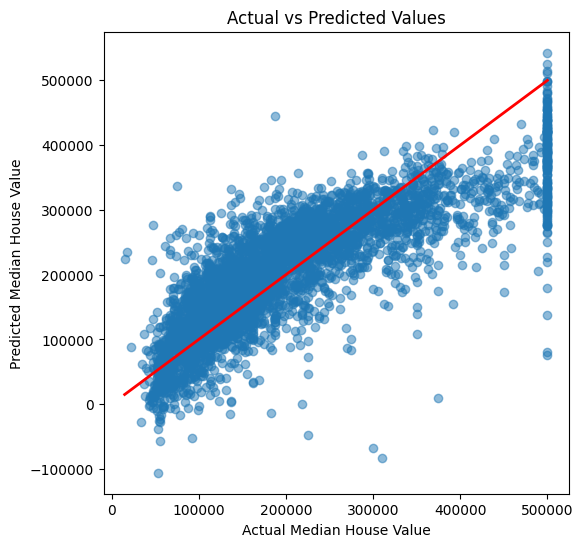

In [145]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Values")
plt.show()


In [146]:
cv_r2 = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    scoring='r2',
    cv=10
)

print("CV R² scores:", cv_r2)
print("Mean CV R²:", cv_r2.mean())
print("Std CV R²:", cv_r2.std())


CV R² scores: [0.6482438  0.67259716 0.65413366 0.64463665 0.66030658 0.67330374
 0.66023457 0.67628571 0.65058034 0.67139426]
Mean CV R²: 0.6611716468059762
Std CV R²: 0.01102060592394176


### Linear regression with VIF Features

In [147]:
df_model_vif = df_model.copy()

In [148]:
def calculate_vif(df, target_col):
    X = df.drop(columns=[target_col])
    vif = pd.DataFrame()
    vif['Feature'] = X.columns
    vif['VIF'] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif.sort_values('VIF', ascending=False)


while True:
    vif_df = calculate_vif(df_model_vif, 'Median_House_Value')
    max_vif = vif_df.iloc[0]['VIF']
    max_feature = vif_df.iloc[0]['Feature']

    if max_vif > 10:
        print(f"Dropping {max_feature} (VIF={max_vif:.2f})")
        df_model_vif.drop(columns=[max_feature], inplace=True)
    else:
        break


Dropping Longitude (VIF=51207.66)
Dropping Latitude (VIF=23872.18)
Dropping Tot_Rooms (VIF=10631.31)
Dropping Households (VIF=3802.43)
Dropping Population (VIF=2480.05)
Dropping income_rooms_interaction (VIF=1525.89)
Dropping bedrooms_per_room (VIF=768.69)
Dropping Distance_to_SanFrancisco (VIF=731.31)
Dropping rooms_per_household (VIF=393.97)
Dropping Distance_to_coast (VIF=192.54)
Dropping population_per_household (VIF=87.06)
Dropping Distance_to_SanDiego (VIF=64.16)
Dropping Tot_Bedrooms (VIF=30.63)


In [150]:
df_model_vif.shape

(20640, 9)

In [151]:
X1 = df_model_vif.drop('Median_House_Value', axis=1)
y1 = df_model_vif['Median_House_Value']

X_train, X_test, y_train, y_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42
)

sc_vif = StandardScaler()
X_train_vif = sc_vif.fit_transform(X_train)
X_test_vif = sc_vif.transform(X_test)
scaler

StandardScaler()

In [154]:
lr_vif = LinearRegression()
lr_vif.fit(X_train, y_train)
# Predictions
y_pred_test_vif = lr_vif.predict(X_test)
y_pred_train_vif = lr_vif.predict(X_train)

# Metrics
mse_vif = mean_squared_error(y_test, y_pred_test_vif)
r2_test_vif = r2_score(y_test, y_pred_test_vif)
r2_train_vif = r2_score(y_train, y_pred_train_vif)

print("MSE:", mse_vif)
print("Train R² Score:", r2_train_vif)
print("Test R² Score:", r2_test_vif)


MSE: 5251726174.685952
Train R² Score: 0.5821615094106816
Test R² Score: 0.5868569585445851


### Linear Regression with Regularization 

In [155]:
df_model_reg = df_model.copy()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [158]:
X2 = df_model_reg.drop(columns=['Median_House_Value'])
y2 = df_model_reg['Median_House_Value']


X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42
)

scaler_x = StandardScaler()

X2_train_scaled = scaler_x.fit_transform(X2_train)
X2_test_scaled = scaler_x.transform(X2_test)

scaler_x

StandardScaler()

In [162]:
lr_x = Ridge(alpha=1.0)
lr_x.fit(X2_train_scaled, y2_train)
y_pred_x = lr_x.predict(X2_test_scaled)
train_r2_x = lr_x.score(X2_train_scaled, y2_train)
test_r2_x = lr_x.score(X2_test_scaled, y2_test)
mse_x = mean_squared_error(y2_test, y_pred_x)

print("MSE:", mse_x)
print("Train R² Score:", train_r2_x)
print("Test R² Score:", test_r2_x)

MSE: 4355814293.68846
Train R² Score: 0.6644098547073707
Test R² Score: 0.6573365964920984


In [163]:
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])
ridge_cv.fit(X2_train_scaled, y2_train)

best_alpha = ridge_cv.alpha_
best_test_r2 = ridge_cv.score(X2_test_scaled, y2_test)

best_alpha, best_test_r2


(np.float64(10.0), 0.6574129261230209)

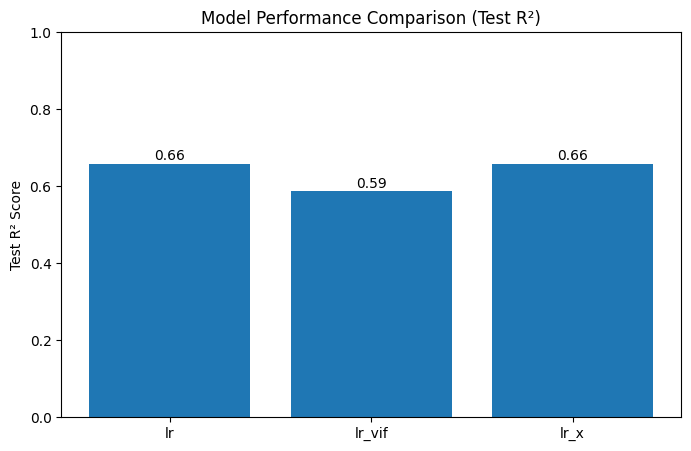

In [164]:
import matplotlib.pyplot as plt

models = ['lr', 'lr_vif', 'lr_x']
test_r2_scores = [
    r2_test,
    r2_test_vif,
    test_r2_x
]

plt.figure(figsize=(8, 5))
plt.bar(models, test_r2_scores)
plt.ylabel('Test R² Score')
plt.title('Model Performance Comparison (Test R²)')
plt.ylim(0, 1)

for i, v in enumerate(test_r2_scores):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()
